# **Prediction Model Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px

Here,We'll start by importing the required libraries for data handling ,split data, visualization, machine learning and evaluate.

In [ ]:
file_path = "/content/IMDb Movies India.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In this step we reads the dataset from the uploaded file and Displays the first five rows to understand its structure.(i have used the unicode encoding method)

In [ ]:
print(df.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


We are now checking how many missing values are present in each column of our dataset.

In [ ]:
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


Display of all the columns to perform further tasks.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
categorical_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
encoder = LabelEncoder()
for col in categorical_columns:
    if col in df.columns:
        df[col] = encoder.fit_transform(df[col].astype(str))
numerical_columns = ['Votes', 'Rating']
df[numerical_columns] = df[numerical_columns].apply(pd.to_numeric, errors='coerce')
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
df_categorical = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
df_categorical = df_categorical.fillna('Unknown')
df_numeric = df[['Votes', 'Rating']]
df_numeric = df_numeric.fillna(0)
df_numeric.head()

,Votes,Rating
0,-2.252404e-16,8.995936e-16
1,-8.942463e-01,1.173266e+00
2,-2.252404e-16,8.995936e-16
3,-6.802729e-01,-1.460150e+00
4,-2.252404e-16,8.995936e-16


Now we convert categorical variables (Genre, Director, Actor 1,Actor 2,Actor 3) into numerical values.
Standardizes numerical features like Vote and Rating.

In [ ]:
!pip install plotly seaborn
import plotly.express as px
import plotly.graph_objects as go

We use matplotlib, seaborn, and plotly for static and interactive visualizations, data visualization & interactive analysis

# **Data Visualizations**

**Feature Correlation Heatmap**



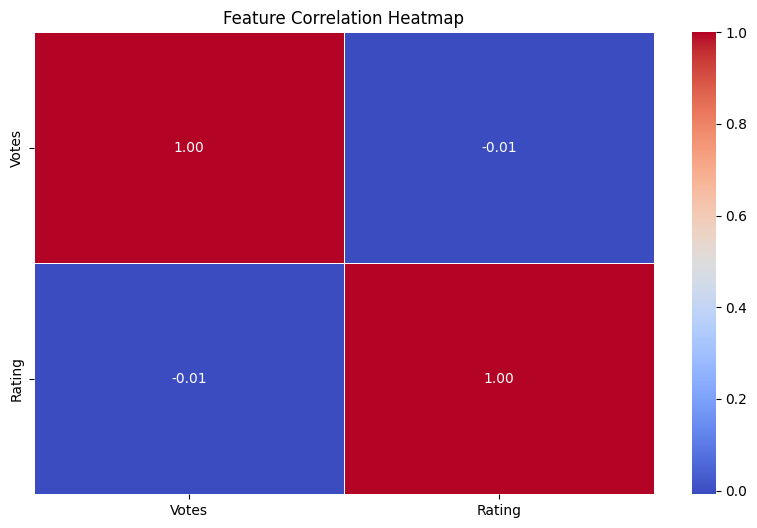

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

It helps in understanding feature relationships.

**Interactive Scatter Plot (Votes vs. Rating)**

In [ ]:
fig = px.scatter(df, x="Votes", y="Rating", color="Genre", hover_data=["Name"])
fig.update_layout(title="Votes vs Rating", xaxis_title="Votes", yaxis_title="Rating")
fig.show()

 It identifies the impact of votes on ratings across different genres.

**Distribution of Ratings**

In [ ]:
fig = px.histogram(df, x="Rating", nbins=30, marginal="box", title="Rating Distribution")
fig.show()

Shows the distribution or spread of ratings.

**Genre-Wise Average Ratings**

In [ ]:
genre_avg = df.groupby("Genre")["Rating"].mean().reset_index()
fig = px.bar(genre_avg, x="Genre", y="Rating", color="Rating", title="Average Rating by Genre")
fig.show()

Helps understand which genres have higher average ratings.

**Box Plot for Rating Distribution by Genre**

In [ ]:
fig = px.box(df, x="Genre", y="Rating", color="Genre", title="Box Plot of Ratings by Genre")
fig.show()

Visualizes rating spread per genre.

**Director Influence on Ratings**

In [ ]:
top_directors = df.groupby("Director")["Rating"].mean().reset_index().sort_values(by="Rating", ascending=False).head(10)
fig = px.bar(top_directors, x="Director", y="Rating", color="Rating", title="Top 10 Directors by Average Rating")
fig.show()

Shows which directors consistently produce high-rated movies.

# **Time-Series Analysis (Yearly Trends in Ratings & Votes)**

In [ ]:
!pip install plotly seaborn pandas scikit-learn streamlit

Now we have installed a dependency so that we'll now analyze how movie ratings and votes change over time.

In [ ]:
df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])

In [ ]:
df_yearly = df.groupby("Year")[["Rating", "Votes"]].mean().reset_index()
fig = px.line(df_yearly, x="Year", y="Rating", title="Average Movie Rating Over Years")
fig.show()
fig = px.line(df_yearly, x="Year", y="Votes", title="Average Votes Over Years")
fig.show()

Yearly Trends in Ratings & Votes ,helps us find insights through yearwise ups and downs.

# **Machine Learning Model: Movie Rating Prediction**

In [ ]:
X = df[['Year', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Genre']]
y = df['Rating']
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in ['Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Genre']:
    X[col] = encoder.fit_transform(X[col].astype(str))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<ipython-input-69-3322fac02169>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-69-3322fac02169>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-69-3322fac02169>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-69-3322fac

Here we have split the data into training and testing sets.

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R² Score:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 1.0296075840630747
Linear Regression R² Score: 0.012788734961585058


For Model-1 we have used linear regression.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Model
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R² Score:", r2_score(y_test, y_pred_rf))


Random Forest RMSE: 0.8861715277968742
Random Forest R² Score: 0.26868880589985267


For Model-2 we have used random forest regression.